# Three Questions 
1.which country provide most revenue?
2.what it the sale trend of month?
3.which is the bestseller?



In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Online_Retail.csv',encoding ='ISO-8859-1',dtype=str)
print(df.info(),df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   InvoiceNo    541909 non-null  object
 1   StockCode    541909 non-null  object
 2   Description  540455 non-null  object
 3   Quantity     541909 non-null  object
 4   InvoiceDate  541909 non-null  object
 5   UnitPrice    541909 non-null  object
 6   CustomerID   406829 non-null  object
 7   Country      541909 non-null  object
dtypes: object(8)
memory usage: 33.1+ MB
None   InvoiceNo StockCode                          Description Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER        6   
1    536365     71053                  WHITE METAL LANTERN        6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER        8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE        6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.        6  

1️⃣ Revenue by Country (excluding UK)

The UK dominates the dataset, so it was removed to better compare other countries.

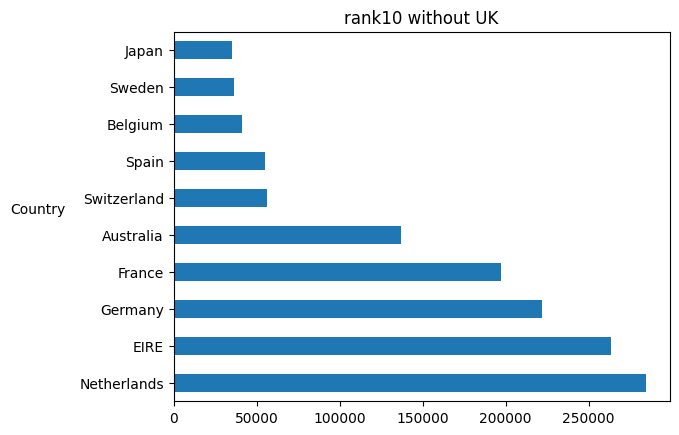

In [18]:

df['Quantity'] = pd.to_numeric(df['Quantity'],errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'],errors='coerce')
df['Revenue'] = df['Quantity'] * df['UnitPrice']

country_rank10 = df[df['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False)[:10]

ax = country_rank10.plot(kind='barh',title='rank10 without UK')
ax.set_ylabel('Country',rotation=0,labelpad=30)
plt.xticks(rotation=0)
plt.show()

Result visualization:

Top countries by revenue include:

Netherlands

EIRE

Germany

France

Australia

2️⃣ Monthly Sales Trend

Monthly revenue trend was analyzed using to_period('M').

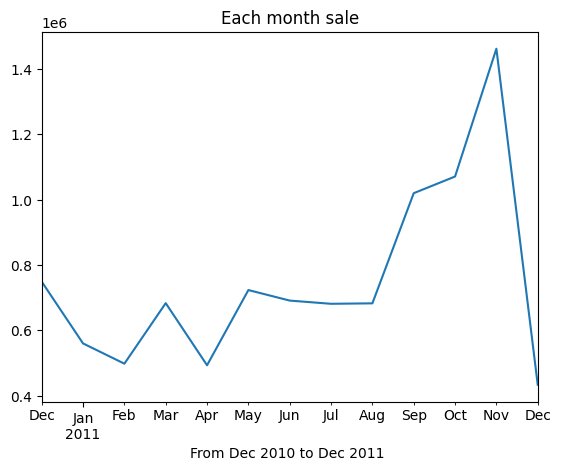

In [19]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
sale_trend_month = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum() 

sale_trend_month.plot(title='Each month sale',kind='line')
plt.xlabel('From Dec 2010 to Dec 2011 ')
plt.show()

Insight:

Sales increased significantly toward the end of the year.

Peak sales occurred around November, likely due to holiday shopping.

3️⃣ Top 10 Bestselling Products


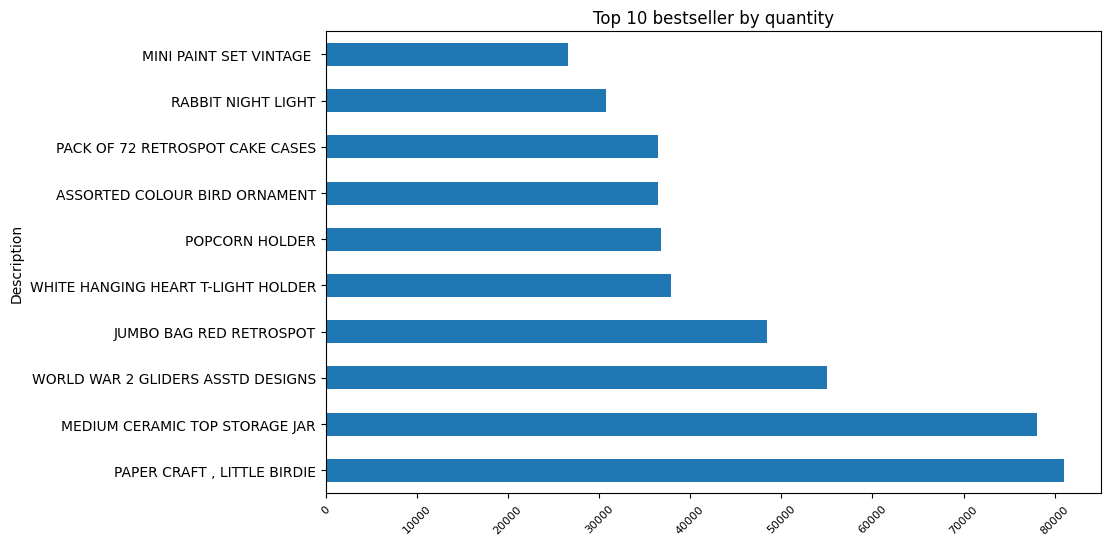

In [22]:

bestseller = df[df['Quantity']>0].groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

bestseller.plot(kind='barh',figsize=(10,6),title='Top 10 bestseller by quantity')

plt.xticks(rotation=45,fontsize=8)
plt.show()

Top products include:

PAPER CRAFT , LITTLE BIRDIE

MEDIUM CERAMIC TOP STORAGE JAR

WORLD WAR 2 GLIDERS ASSTD DESIGNS

JUMBO BAG RED RETROSPOT

📊 Visualization

Visualizations were created using Matplotlib.

Examples include:

Revenue by country (bar chart)

Monthly revenue trend (line chart)

Top 10 bestselling products (bar chart)

🛠 Tools Used

Python

Pandas

Matplotlib

Jupyter Notebook